In [15]:
# ============================================================
# Linear Regression Baseline Model (Bike Sharing Demand)
# Dataset: hour_clean.csv (preprocessed)
# Goal: Predict hourly bike rental demand (cnt) using time + weather + calendar features, using OLS and Ridge regression models
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 1) Load cleaned dataset
# -----------------------------

df = pd.read_csv("../data/processed/hour_clean.csv")

print("Shape:", df.shape)
print("First 5 rows:")
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

Shape: (17379, 20)
First 5 rows:


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt,season_label,weather_label,year_label,day_type_label,temp_celsius,humidity_pct,windspeed_kmh
0,1,1,0,1,0,0,6,0,1,0.24,0.81,0.0,16,Spring,Clear,2011,Weekend/Holiday,9.8,81.0,0.0
1,2,1,0,1,1,0,6,0,1,0.22,0.80,0.0,40,Spring,Clear,2011,Weekend/Holiday,9.0,80.0,0.0
2,3,1,0,1,2,0,6,0,1,0.22,0.80,0.0,32,Spring,Clear,2011,Weekend/Holiday,9.0,80.0,0.0
3,4,1,0,1,3,0,6,0,1,0.24,0.75,0.0,13,Spring,Clear,2011,Weekend/Holiday,9.8,75.0,0.0
4,5,1,0,1,4,0,6,0,1,0.24,0.75,0.0,1,Spring,Clear,2011,Weekend/Holiday,9.8,75.0,0.0



Columns:
['instant', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'cnt', 'season_label', 'weather_label', 'year_label', 'day_type_label', 'temp_celsius', 'humidity_pct', 'windspeed_kmh']


In [5]:
# -----------------------------
# 2) Feature engineering (cyclical time encoding)
# -----------------------------
# Linear regression cannot naturally represent circular patterns like hour-of-day or month.
# Sine/cosine encoding preserves cyclic nature (23 -> 0 is "close" again).

df["hr_sin"] = np.sin(2 * np.pi * df["hr"] / 24)
df["hr_cos"] = np.cos(2 * np.pi * df["hr"] / 24)

df["mnth_sin"] = np.sin(2 * np.pi * df["mnth"] / 12)
df["mnth_cos"] = np.cos(2 * np.pi * df["mnth"] / 12)

print("Cyclical columns added:", [c for c in ["hr_sin","hr_cos","mnth_sin","mnth_cos"] if c in df.columns])

Cyclical columns added: ['hr_sin', 'hr_cos', 'mnth_sin', 'mnth_cos']


In [6]:
# -----------------------------
# 3) Define target (y) and features (X)
# -----------------------------
# Target variable: total bike rentals

y = df["cnt"].astype(float)

# Categorical features (using label columns for interpretability)
categorical_features = [
    "season_label",
    "weather_label",
    "year_label",
    "day_type_label",
    "weekday",
    "holiday",
    "workingday",
]

# Numeric features (use human-readable units when available)
numeric_features = [
    "temp_celsius",
    "humidity_pct",
    "windspeed_kmh",
    "hr_sin", "hr_cos",
    "mnth_sin", "mnth_cos",
]

# Build feature matrix
X = df[categorical_features + numeric_features].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (17379, 14)
y shape: (17379,)


,season_label,weather_label,year_label,day_type_label,weekday,holiday,workingday,temp_celsius,humidity_pct,windspeed_kmh,hr_sin,hr_cos,mnth_sin,mnth_cos
0,Spring,Clear,2011,Weekend/Holiday,6,0,0,9.8,81.0,0.0,0.000000,1.000000,0.5,0.866025
1,Spring,Clear,2011,Weekend/Holiday,6,0,0,9.0,80.0,0.0,0.258819,0.965926,0.5,0.866025
2,Spring,Clear,2011,Weekend/Holiday,6,0,0,9.0,80.0,0.0,0.500000,0.866025,0.5,0.866025
3,Spring,Clear,2011,Weekend/Holiday,6,0,0,9.8,75.0,0.0,0.707107,0.707107,0.5,0.866025
4,Spring,Clear,2011,Weekend/Holiday,6,0,0,9.8,75.0,0.0,0.866025,0.500000,0.5,0.866025


In [7]:
# -----------------------------
# 4) Train/Test split (time-aware)
# -----------------------------
# To mimic real forecasting, we train on 2011 and test on 2012 (no random shuffling).

train_mask = df["year_label"].astype(str).eq("2011")
test_mask  = df["year_label"].astype(str).eq("2012")

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_test, y_test   = X.loc[test_mask],  y.loc[test_mask]

print("Train rows:", X_train.shape[0], "| Test rows:", X_test.shape[0])
print("Train years:", df.loc[train_mask, "year_label"].unique())
print("Test years:", df.loc[test_mask, "year_label"].unique())

Train rows: 8645 | Test rows: 8734
Train years: [2011]
Test years: [2012]


In [8]:
# -----------------------------
# 5) Preprocessing pipeline
# -----------------------------
# - Standardize numeric columns (mean=0, std=1)
# - One-hot encode categorical columns
# This ensures a fair linear model fit and makes coefficients comparable.

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

print("Preprocess pipeline created successfully.")

Preprocess pipeline created successfully.


In [9]:
# -----------------------------
# 6) Build and train linear models
# -----------------------------

# OLS Linear Regression: classic baseline
ols_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

# Ridge Regression: still "linear regression", but with L2 regularization to reduce overfitting
ridge_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(alpha=10.0))
])

# Fit models
ols_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)

print("Models trained successfully.")

Models trained successfully.


In [11]:
# -----------------------------
# 7) Predict on test set
# -----------------------------

pred_ols = ols_model.predict(X_test)
pred_ridge = ridge_model.predict(X_test)

# Linear models can output negative predictions; bike rentals cannot be negative.
# Clipping is used to improve interpretability.
pred_ols = np.clip(pred_ols, 0, None)
pred_ridge = np.clip(pred_ridge, 0, None)

print("Predictions generated.")
print("OLS prediction min/max:", pred_ols.min(), pred_ols.max())
print("Ridge prediction min/max:", pred_ridge.min(), pred_ridge.max())

Predictions generated.
OLS prediction min/max: 0.0 348.70786939033604
Ridge prediction min/max: 0.0 348.8302334977965


In [12]:
# -----------------------------
# 8) Evaluate performance
# -----------------------------

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def report(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)   # no squared=
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: RMSE={rmse:.2f} | MAE={mae:.2f} | R²={r2:.3f}")

report("Linear Regression (OLS)", y_test, pred_ols)
report("Ridge Regression (alpha=10)", y_test, pred_ridge)

Linear Regression (OLS): RMSE=180.76 | MAE=115.74 | R²=0.251
Ridge Regression (alpha=10): RMSE=180.79 | MAE=115.75 | R²=0.251


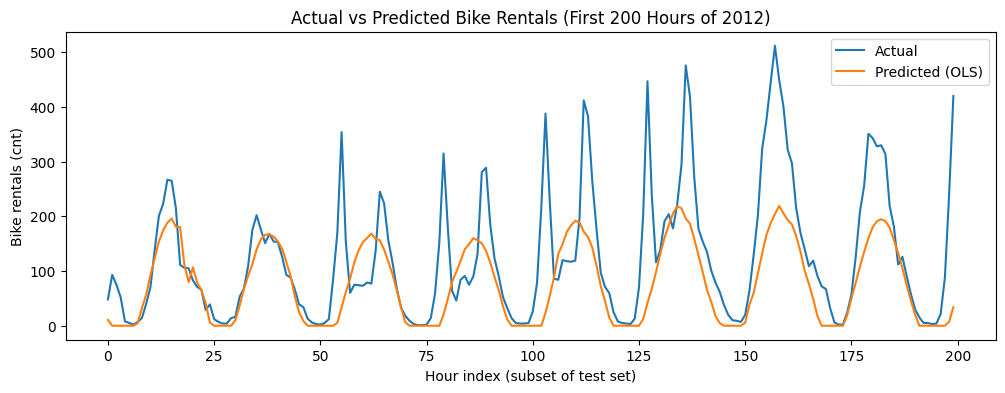

In [13]:
# -----------------------------
# 9) Plot: Actual vs Predicted (first 200 hours of test set)
# -----------------------------

# This is a simple diagnostic to visualize how the model tracks demand.
N = 200

plt.figure(figsize=(12,4))
plt.plot(y_test.reset_index(drop=True).iloc[:N].values, label="Actual")
plt.plot(pd.Series(pred_ols).iloc[:N].values, label="Predicted (OLS)")
plt.title("Actual vs Predicted Bike Rentals (First 200 Hours of 2012)")
plt.xlabel("Hour index (subset of test set)")
plt.ylabel("Bike rentals (cnt)")
plt.legend()
plt.show()

Interpretation of Linear Regression:
The linear regression model provides a baseline for predicting hourly bike rental demand.
The model achieved an RMSE of approximately 181 and an R² of 0.25 on the 2012 test data, indicating that the model explains about 25% of the variance in hourly demand.
While the model captures some relationships between weather conditions, time features, and bike rentals, it struggles to model nonlinear demand patterns such as rush-hour peaks and seasonal changes.